In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [6]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Day,Eddy,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1462,1,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000011,...,1.558529,118.032741,47.992205,1.969122,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1463,1,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000018,...,0.688838,108.004573,52.019741,1.602291,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1464,1,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000011,...,0.819551,141.148836,74.035424,1.269457,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1465,1,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000016,...,0.787603,111.650721,56.591801,1.544380,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.975521,184.917296
4,1466,1,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000014,...,1.007249,115.925719,57.471319,1.538338,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.064961,181.172744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106155,10646,2826,CE,153.757172,-37.513498,182,61,518.287017,300.848692,-0.000026,...,0.988587,91.984251,31.359836,1.138712,46.900904,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752301,4.278077
106156,10647,2826,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.969387,78.707595,25.393893,1.031663,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165619,28.370574
106157,10648,2826,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000026,...,0.989895,61.298208,19.369553,1.017029,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
106158,10649,2826,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000025,...,0.889591,64.546558,19.604126,1.136121,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [8]:
# Lifespan Day Index
day_idxs = []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy()
    if len(df):
        day_idxs.extend(df.Day-df.Day.iloc[0])
df_eddies['Day_idx'] = day_idxs


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


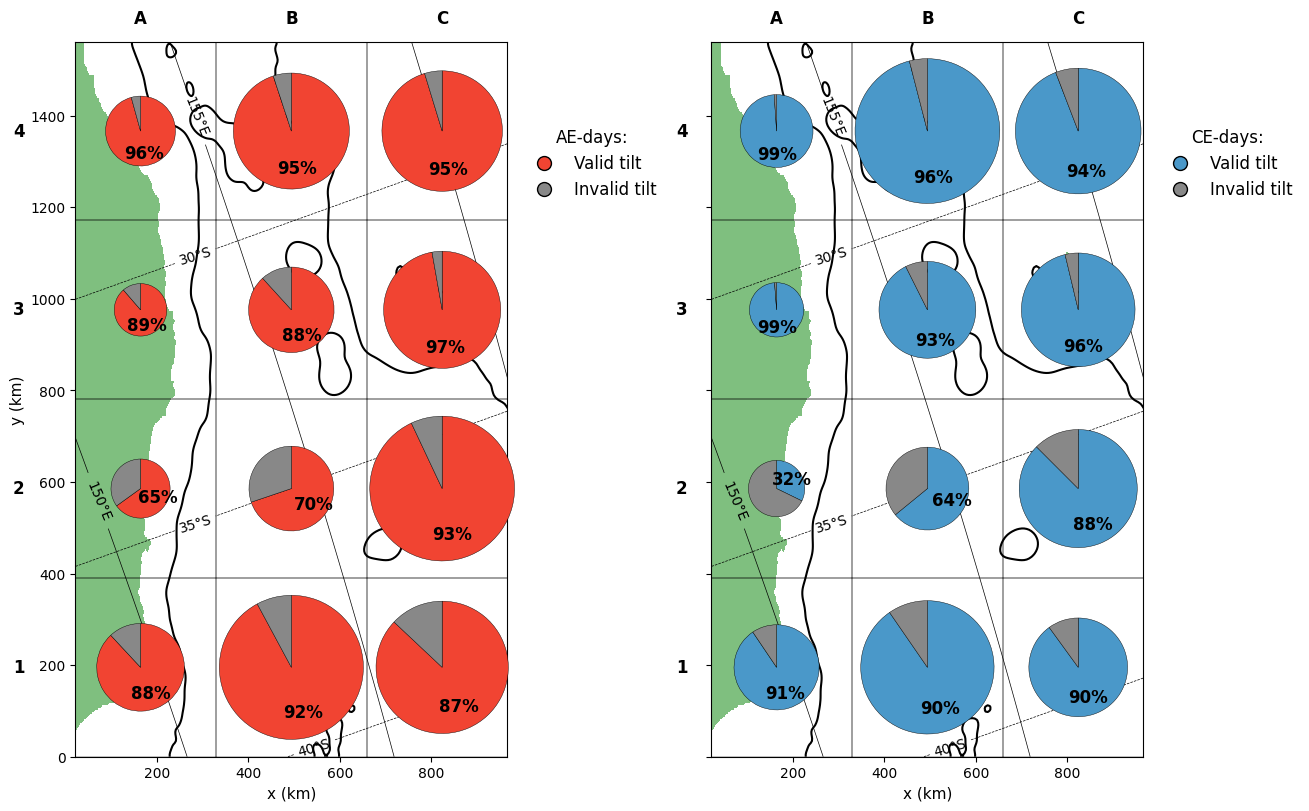

In [9]:
ncols, nrows = 3, 4
x_edges = np.linspace(X_grid.min(), X_grid.max(), ncols + 1)
y_edges = np.linspace(Y_grid.min(), Y_grid.max(), nrows + 1)
cell_w = (X_grid.max() - X_grid.min()) / ncols
cell_h = (Y_grid.max() - Y_grid.min()) / nrows

def cell_counts_valid_invalid(df):
    out, vmax = {}, 0
    for i in range(ncols):
        for j in range(nrows):
            x0, x1 = x_edges[i], x_edges[i + 1]
            y0, y1 = y_edges[j], y_edges[j + 1]
            sub = df[(df.xc >= x0) & (df.xc < x1) & (df.yc >= y0) & (df.yc < y1)]
            v = np.count_nonzero(~sub.TiltDis.isna())
            sub_excluding_beg_end = sub[(np.abs(sub.Day_idx - (sub.Age - 1)) > 2) & (sub.Day_idx > 2)]
            iv = np.count_nonzero(sub_excluding_beg_end.TiltDis.isna())
            c = np.array([v, iv], dtype=int)
            out[(i, j)] = c
            vmax = max(vmax, v)
    return out, (1 if vmax == 0 else vmax)

def make_autopct(vals):
    total = np.sum(vals)
    if total == 0:
        return lambda pct: ""

    valid_pct = int(np.round(100 * vals[0] / total))
    called = {'done': False}

    def _inner(pct):
        if not called['done']:
            called['done'] = True
            return f"{valid_pct}%"
        return ""
    return _inner

def add_pie_valid_invalid(ax, x0, y0, counts, tmax, frac=0.25, tick_flag=False, title='', color=plt.cm.Greens(0.6)):
    if counts is None or counts.sum() == 0:
        return
    s_base = frac * min(cell_w, cell_h)
    scale = 0.35 + 0.65 * (counts[0] / tmax)
    s = s_base * scale
    iax = ax.inset_axes([x0 - s/2, y0 - s/2, s, s], transform=ax.transData)
    iax.pie(
        counts,
        startangle=90,
        counterclock=False,
        colors=[color, plt.cm.Greys(0.55)],
        wedgeprops={'edgecolor': 'k', 'linewidth': 0.3},
        autopct=make_autopct(counts),
        pctdistance=0.65,
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'k'}
    )
    iax.set_aspect('equal')
    iax.set_xticks([])
    iax.set_yticks([])
    for spine in iax.spines.values():
        spine.set_visible(False)

    if tick_flag:
        ax.legend(
            handles=[
                plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=color,
                           markeredgecolor='k', markersize=10, label='Valid tilt'),
                plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=plt.cm.Greys(0.55),
                           markeredgecolor='k', markersize=10, label='Invalid tilt')
            ],
            loc='upper right',
            frameon=False,
            fontsize=12,
            bbox_to_anchor=(1.38, 0.9),
            title=title,
            title_fontsize=12
        )

fracs = [1.2, 1.2]
fig, axs = plt.subplots(1, 2, figsize=(13, 8), sharey=True, constrained_layout=True)

colors = [plt.cm.Reds(0.6), plt.cm.Blues(0.6)]
titles = ['AE-days', 'CE-days']
cycs = ['AE', 'CE']

for p, cyc in enumerate(cycs):
    ax = axs[p]
    df = df_eddies[df_eddies.Cyc == cyc]

    ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho == 0, 1, np.nan),
        levels=[0.5, 1.5],
        colors=['g'],
        alpha=0.5
    )
    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=0.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=0.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k')

    ax.axis('equal')
    ax.set_xlim(X_grid.min(), X_grid.max())
    ax.set_ylim(Y_grid.min(), Y_grid.max())

    counts_map, tmax = cell_counts_valid_invalid(df)
    for i in range(ncols):
        for j in range(nrows):
            x0, x1 = x_edges[i], x_edges[i + 1]
            y0, y1 = y_edges[j], y_edges[j + 1]
            xc, yc = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
            tick_flag = (i == 2 and j == 3)
            add_pie_valid_invalid(
                ax, xc, yc, counts_map[(i, j)], tmax,
                frac=fracs[p], tick_flag=tick_flag,
                color=colors[p], title=f'{titles[p]}:'
            )
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], 'k-', lw=0.3)

    col_labels = ['A', 'B', 'C']
    for i in range(ncols):
        xc = 0.5 * (x_edges[i] + x_edges[i + 1])
        ax.text(
            xc,
            y_edges[-1] + 0.02 * (Y_grid.max() - Y_grid.min()),
            col_labels[i],
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

    for j in range(nrows):
        yc = 0.5 * (y_edges[j] + y_edges[j + 1])
        alpha = 0.09 if p==0 else 0.03
        ax.text(
            x_edges[0] - alpha * (X_grid.max() - X_grid.min()),
            yc,
            f"{j+1}",
            ha='right',
            va='center',
            fontsize=12,
            fontweight='bold'
        )

for ax in axs:
    ax.set_xlabel('x (km)', fontsize=11)
axs[0].set_ylabel('y (km)', fontsize=11)

# plt.tight_layout()
plt.show()

